In [41]:
pathtosrc = "../src/1D/"
include(pathtosrc*"integration-path-flow.jl")
include(pathtosrc*"critical-points.jl")
include(pathtosrc*"line-intersection.jl")
include(pathtosrc*"saddle-point-method.jl")

Finding Saddle points using gradient descent...
Checking saddle point contribution using is_contributing...
Calculating gradient ascent and dual thimbles for contributing saddles...
--- Fold (x=-5.0) ---
Saddles: ComplexF64[-2.23606797749979 + 0.0im, 2.23606797749979 + 0.0im]
Identified Contributing Saddles with Gradient Ascent: 
  - -2.23606797749979 + 0.0im
  - 2.23606797749979 + 0.0im

Finding Saddle points using gradient descent...
Checking saddle point contribution using is_contributing...
Calculating gradient ascent and dual thimbles for contributing saddles...
--- Fold (x=-0.1) ---
Saddles: ComplexF64[-0.31622776601683794 + 0.0im, 0.31622776601683794 + 0.0im]
Identified Contributing Saddles with Gradient Ascent: 
  - -0.31622776601683794 + 0.0im
  - 0.31622776601683794 + 0.0im

Finding Saddle points using gradient descent...
Checking saddle point contribution using is_contributing...
Calculating gradient ascent and dual thimbles for contributing saddles...
--- Cusp (x=0.5, y=1.0

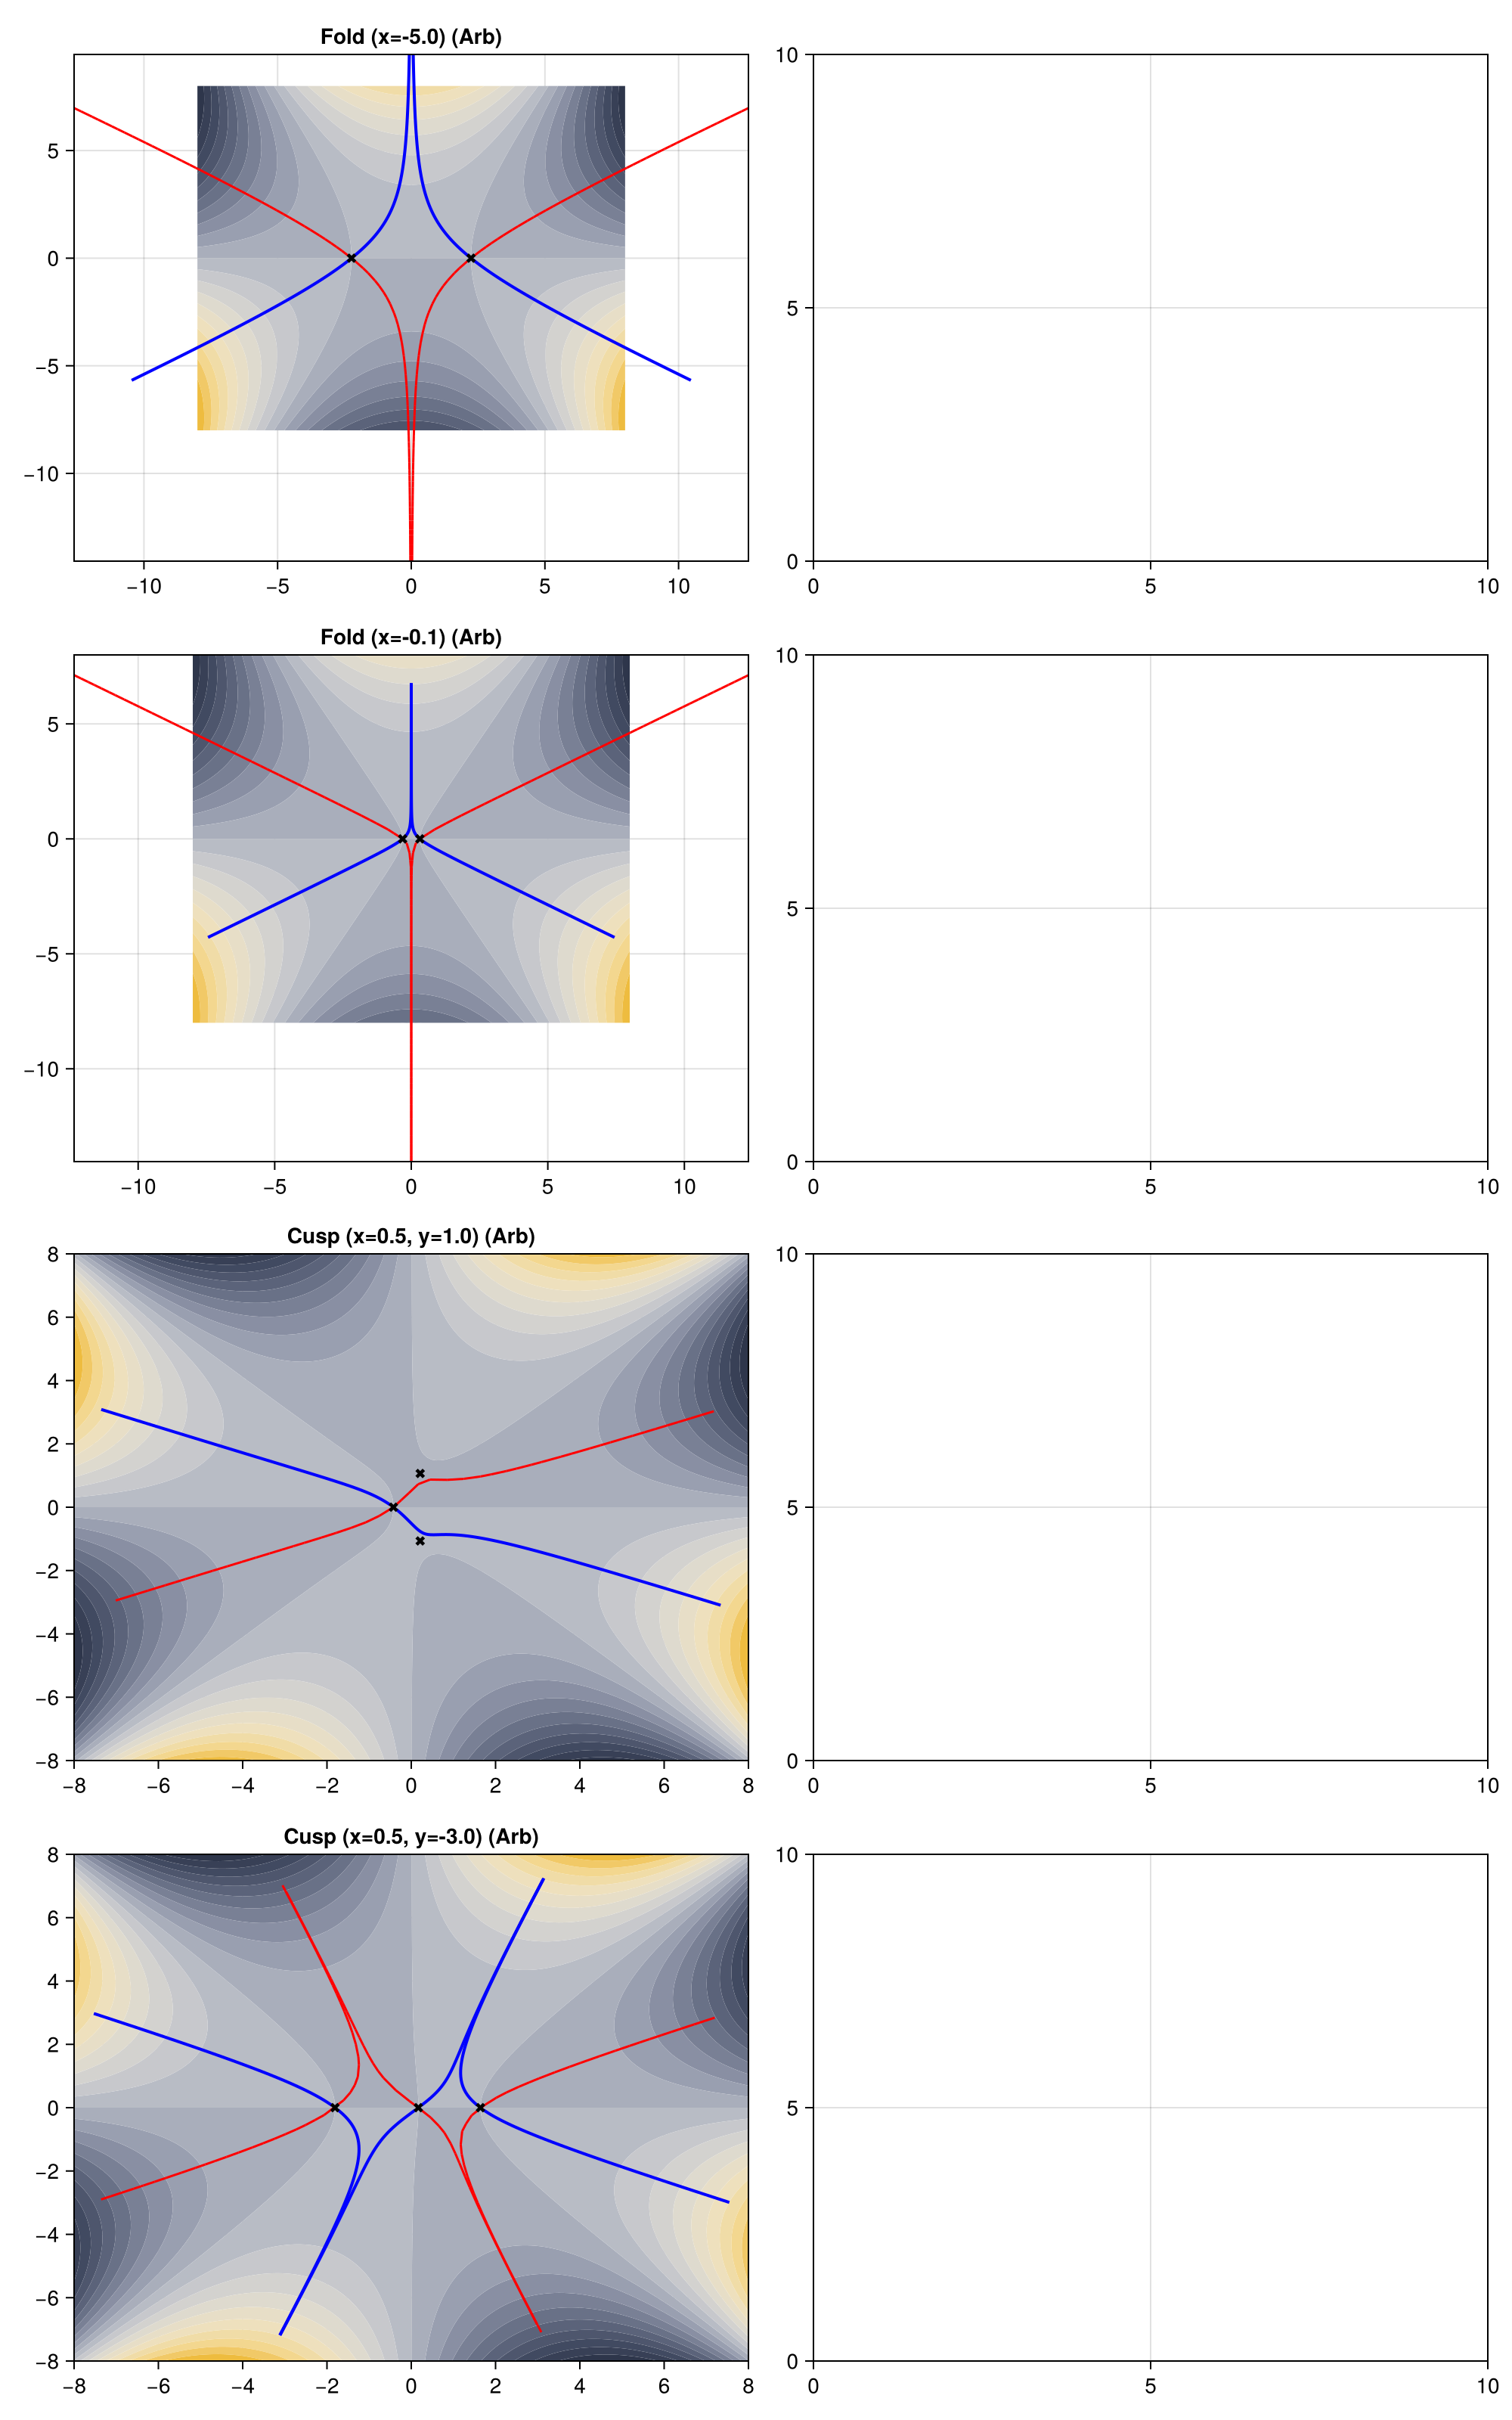

In [42]:
# ==============================================================================
# Cell 1: Canonical Integrals (Fold and Cusp)
# ==============================================================================
import NumericalSteepestDescent: evalphase, evalphase_derivative, evalphase_derivative2, stationary_points, AbstractPhase, PolynomialPhase
using Makie

known_fold_sep = 2.203896418231801
known_fold_cls = 2.392942755791262
known_cusp_sep = 4.309284695915666 + 2.091890021765689im
known_cusp_cls = 0.9304706216791871 - 1.8641341806218967im

function run_and_plot(ax_arb, ax_heu, G, omega, tmin, tmax, title_prefix, exact_val; Nflow=4000, h_threshold=-1000.0, arb_flowstepfactor=0.1, arb_Δinit=0.5, arb_subdividethreshold=0.5)
    println("Finding Saddle points using gradient descent...")
    saddles = stationary_points(G)

    drv(z) = evalphase_derivative(z, G)
    phase(z) = evalphase(z, G)

    println("Checking saddle point contribution using is_contributing...")
    contributing_saddles = [saddle for saddle in saddles if is_contributing(saddle, phase, complex(tmin, 0), complex(tmax, 0))]

    dual_thimbles = []
    println("Calculating gradient ascent and dual thimbles for contributing saddles...")
    for saddle in saddles
        push!(dual_thimbles, flow_up(phase, drv, MyPoint(saddle), arb_flowstepfactor, h_threshold, 1e-10, 100))
    end

    points_arb, simplices_arb = get_thimble(phase, drv, tmin, tmax, 
    Nflow = Nflow, flowstepfactor=arb_flowstepfactor, h_threshold=h_threshold, Δinit=arb_Δinit, subdividethreshold=arb_subdividethreshold)

    println("--- $title_prefix ---")
    println("Saddles: ", saddles)
    println("Identified Contributing Saddles with Gradient Ascent: ")
    for i in eachindex(dual_thimbles)
        thimble = dual_thimbles[i]
        if thimble[2] # Contributing
            println("  - ", saddles[i])
        end
    end
    println()

    treals = range(-8, 8, length=150)
    timags = range(-8, 8, length=150)
    Phi = [phase(Complex(tr, ti)) for tr in treals, ti in timags]

    contourf!(ax_arb, treals, timags, -imag.(Phi), colormap=:grayyellow, levels=20, extendlow=:white, extendhigh=:white)
    
    
    # Plot standard thimbles (red lines)
    for seg in simplices_arb
        if seg.active
            lines!(ax_arb, [reim.(p.coord) for p in points_arb[seg.coord]], color=:red)
        end
    end
    
    # Plot dual thimbles (blue lines)
    for thimbles in dual_thimbles
        for thimble in thimbles[1]
            if !isempty(thimble) && thimbles[2]
                lines!(ax_arb, [reim(p.coord) for p in thimble], color=:blue, linewidth=2)
            end
        end
    end

    scatter!(ax_arb, reim(saddles)..., color=:black, marker=:x)
    
    ax_arb.title = "$title_prefix (Arb)"
end


f_can = Figure(size=(1000, 1600))
run_and_plot(Axis(f_can[1,1]), Axis(f_can[1,2]), PolynomialPhase([0.0, -5.0, 0.0, 1/3]), 1.0, -10.0, 10.0, "Fold (x=-5.0)", known_fold_sep)
run_and_plot(Axis(f_can[2,1]), Axis(f_can[2,2]), PolynomialPhase([0.0, -0.1, 0.0, 1/3]), 1.0, -10.0, 10.0, "Fold (x=-0.1)", known_fold_cls)
run_and_plot(Axis(f_can[3,1]), Axis(f_can[3,2]), PolynomialPhase([0.0, 0.5, 0.5, 0.0, 1/4]), 1.0, -10.0, 10.0, "Cusp (x=0.5, y=1.0)", known_cusp_sep)
run_and_plot(Axis(f_can[4,1]), Axis(f_can[4,2]), PolynomialPhase([0.0, 0.5, -1.5, 0.0, 1/4]), 1.0, -10.0, 10.0, "Cusp (x=0.5, y=-3.0)", known_cusp_cls)

save("output.png", f_can)
f_can